# Swapping Wait-Time Fidelity Fix: Real SeQUeNCe Protocol Simulations

This notebook documents and validates our fix for a timing-related fidelity issue in stock SeQUeNCe swapping.

## Stock issue
In stock behavior, swapped fidelity can be under-sensitive to timing because:

1. Swap-time fidelity may be computed from stale memory-fidelity snapshots instead of refreshed Bell-diagonal states at swap time.
2. Receiver-side fidelity can miss explicit aging from `swap_time` to message-arrival time.

That can make final fidelity less responsive to real waiting asymmetry.

## Our contribution (implemented in `sequence/entanglement_management/swapping.py`)

1. **Swap-time refresh in `EntanglementSwappingA`**:
   refresh both memories via `bds_decohere()` before computing `degradation * f1 * f2`.
2. **Carry `swap_time` in swap result message**.
3. **Receiver-side transit aging in `EntanglementSwappingB`**:
   reconstruct Bell-diagonal state from message fidelity and age it from `swap_time` to receive-time.

## What this notebook shows

Using real SeQUeNCe protocol execution on a 3-node chain (`r1-r2-r3`), we compare:
- `stock_timing`: stock timing behavior,
- `wait_aware_timing`: behavior with the above fix.

The simulation uses SeQUeNCe classes directly (`Timeline`, `QuantumRouter`, `ClassicalChannel`, `EntanglementSwappingA/B`).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sequence.kernel.timeline import Timeline
from sequence.kernel.event import Event
from sequence.kernel.process import Process
from sequence.topology.node import QuantumRouter
from sequence.components.optical_channel import ClassicalChannel
from sequence.kernel.quantum_manager import QuantumManager
from sequence.constants import BELL_DIAGONAL_STATE_FORMALISM
from sequence.entanglement_management.swapping import (
    EntanglementSwappingA,
    EntanglementSwappingB,
    EntanglementSwappingMessage,
    SwappingMsgType,
)
from sequence.resource_management.memory_manager import MemoryInfo

sns.set_theme(style='whitegrid')


## Parameters

Single coherence-time control: set only `COHERENCE_TIME_S` in the next cell.\n

In [2]:
F_LEFT_RAW = 0.9474
F_RIGHT_RAW = 0.9677
SWAP_DEGRADATION = 0.95

COHERENCE_TIME_S = 0.005

SWAP_TIME_PS = int(2.0e9)      # 2 ms
MSG_DELAY_PS = int(0.35e9)     # 0.35 ms
EXPIRE_TIME_PS = int(100e9)

TRIALS = 500
SEED = 123


## Helpers: stock-mode monkeypatches

In [3]:
def stock_refresh(memory):
    return float(memory.fidelity)


def stock_received_message(self, src: str, msg: EntanglementSwappingMessage):
    assert src == self.remote_node_name
    if msg.fidelity > 0 and self.owner.timeline.now() < msg.expire_time:
        self.memory.fidelity = float(msg.fidelity)
        self.memory.entangled_memory["node_id"] = msg.remote_node
        self.memory.entangled_memory["memo_id"] = msg.remote_memo
        self.memory.update_expire_time(msg.expire_time)
    else:
        self.memory.fidelity = 0.0


def new_received_message(self, src: str, msg: EntanglementSwappingMessage):
    assert src == self.remote_node_name
    if msg.fidelity > 0 and self.owner.timeline.now() < msg.expire_time:
        self.memory.fidelity = float(msg.fidelity)
        self.memory.entangled_memory["node_id"] = msg.remote_node
        self.memory.entangled_memory["memo_id"] = msg.remote_memo

        remote_memory = self.owner.timeline.get_entity_by_name(msg.remote_memo)
        swap_time = msg.swap_time if msg.swap_time is not None else self.owner.timeline.now()
        if remote_memory is not None and self.memory.decoherence_errors is not None:
            rem = max(0.0, 1.0 - msg.fidelity)
            swapped_state = [msg.fidelity, rem / 3, rem / 3, rem / 3]
            self.owner.timeline.quantum_manager.set([self.memory.qstate_key, remote_memory.qstate_key], swapped_state)
            self.memory.last_update_time = int(swap_time)
            remote_memory.last_update_time = int(swap_time)
            self.memory.bds_decohere()
            refreshed = float(self.owner.timeline.quantum_manager.get(self.memory.qstate_key).state[0])
            self.memory.fidelity = refreshed
            remote_memory.fidelity = refreshed

        self.memory.update_expire_time(msg.expire_time)
    else:
        self.memory.fidelity = 0.0


## One real SeQUeNCe trial

We prepare two elementary entangled pairs with configurable waiting durations before swapping, then execute swapping at `r2` on the timeline.


In [4]:
def set_pair_state(qm, mem_a, mem_b, F):
    rem = max(0.0, 1 - F)
    state = [F, rem/3, rem/3, rem/3]
    qm.set([mem_a.qstate_key, mem_b.qstate_key], state)


def configure_pair(mem_local, mem_remote, remote_node_name, local_node_name, F_raw, last_update_time_ps):
    mem_local.fidelity = float(F_raw)
    mem_remote.fidelity = float(F_raw)
    mem_local.entangled_memory = {"node_id": remote_node_name, "memo_id": mem_remote.name}
    mem_remote.entangled_memory = {"node_id": local_node_name, "memo_id": mem_local.name}
    mem_local.last_update_time = int(last_update_time_ps)
    mem_remote.last_update_time = int(last_update_time_ps)
    mem_local.generation_time = int(last_update_time_ps)
    mem_remote.generation_time = int(last_update_time_ps)
    mem_local.update_expire_time(EXPIRE_TIME_PS)
    mem_remote.update_expire_time(EXPIRE_TIME_PS)


def run_single_trial(wait_left_s: float, wait_right_s: float, mode: str):
    QuantumManager.set_global_manager_formalism(BELL_DIAGONAL_STATE_FORMALISM)
    tl = Timeline(SWAP_TIME_PS + MSG_DELAY_PS + int(2e8))

    r1 = QuantumRouter('r1', tl, memo_size=1)
    r2 = QuantumRouter('r2', tl, memo_size=2)
    r3 = QuantumRouter('r3', tl, memo_size=1)

    for node in [r1, r2, r3]:
        ma = node.get_components_by_type('MemoryArray')[0]
        ma.update_memory_params('coherence_time', COHERENCE_TIME_S)
        ma.update_memory_params('decoherence_errors', [1/3, 1/3, 1/3])
        for mem in ma:
            mem.decoherence_rate = 1 / COHERENCE_TIME_S

    for src in [r1, r2, r3]:
        for dst in [r1, r2, r3]:
            if src is dst:
                continue
            cc = ClassicalChannel(f'cc_{src.name}_{dst.name}', tl, distance=1e3, delay=MSG_DELAY_PS)
            cc.set_ends(src, dst.name)

    m_r1 = r1.get_components_by_type('MemoryArray')[0][0]
    m_r2_left = r2.get_components_by_type('MemoryArray')[0][0]
    m_r2_right = r2.get_components_by_type('MemoryArray')[0][1]
    m_r3 = r3.get_components_by_type('MemoryArray')[0][0]

    left_last = max(1, SWAP_TIME_PS - int(wait_left_s * 1e12))
    right_last = max(1, SWAP_TIME_PS - int(wait_right_s * 1e12))

    configure_pair(m_r2_left, m_r1, 'r1', 'r2', F_LEFT_RAW, left_last)
    configure_pair(m_r2_right, m_r3, 'r3', 'r2', F_RIGHT_RAW, right_last)

    set_pair_state(tl.quantum_manager, m_r2_left, m_r1, F_LEFT_RAW)
    set_pair_state(tl.quantum_manager, m_r2_right, m_r3, F_RIGHT_RAW)

    a = EntanglementSwappingA(r2, 'A', m_r2_left, m_r2_right, success_prob=1.0, degradation=SWAP_DEGRADATION)
    b1 = EntanglementSwappingB(r1, 'B1', m_r1)
    b3 = EntanglementSwappingB(r3, 'B3', m_r3)

    r2.protocols.append(a)
    r1.protocols.append(b1)
    r3.protocols.append(b3)

    a.set_others('B1', 'r1', [m_r1.name])
    a.set_others('B3', 'r3', [m_r3.name])
    b1.set_others('A', 'r2', [m_r2_left.name])
    b3.set_others('A', 'r2', [m_r2_right.name])

    orig_start = EntanglementSwappingA.start
    orig_refresh = EntanglementSwappingA._refresh_memory_fidelity
    orig_recv = EntanglementSwappingB.received_message

    if mode == 'stock_timing':
        EntanglementSwappingA._refresh_memory_fidelity = staticmethod(stock_refresh)
        EntanglementSwappingB.received_message = stock_received_message
    else:
        EntanglementSwappingB.received_message = new_received_message

    swap_metrics = {'swap_fidelity_at_a': 0.0, 'left_f_at_a': 0.0, 'right_f_at_a': 0.0}

    def patched_start(self):
        # Protocol-faithful swap flow without run_circuit dependency.
        if mode == 'wait_aware_timing':
            f1 = self._refresh_memory_fidelity(self.left_memo)
            f2 = self._refresh_memory_fidelity(self.right_memo)
        else:
            f1 = float(self.left_memo.fidelity)
            f2 = float(self.right_memo.fidelity)

        swap_metrics['left_f_at_a'] = float(f1)
        swap_metrics['right_f_at_a'] = float(f2)

        if self.owner.get_generator().random() < self.success_probability():
            fidelity = self.updated_fidelity(float(f1), float(f2))
            swap_metrics['swap_fidelity_at_a'] = float(fidelity)
            self.is_success = True
            expire_time = min(self.left_memo.get_expire_time(), self.right_memo.get_expire_time())
            swap_time = self.owner.timeline.now()

            msg_l = EntanglementSwappingMessage(
                SwappingMsgType.SWAP_RES,
                self.left_protocol_name,
                fidelity=fidelity,
                remote_node=self.right_memo.entangled_memory['node_id'],
                remote_memo=self.right_memo.entangled_memory['memo_id'],
                expire_time=expire_time,
                meas_res=[],
                swap_time=swap_time,
            )
            msg_r = EntanglementSwappingMessage(
                SwappingMsgType.SWAP_RES,
                self.right_protocol_name,
                fidelity=fidelity,
                remote_node=self.left_memo.entangled_memory['node_id'],
                remote_memo=self.left_memo.entangled_memory['memo_id'],
                expire_time=expire_time,
                meas_res=[],
                swap_time=swap_time,
            )
        else:
            msg_l = EntanglementSwappingMessage(SwappingMsgType.SWAP_RES, self.left_protocol_name, fidelity=0)
            msg_r = EntanglementSwappingMessage(SwappingMsgType.SWAP_RES, self.right_protocol_name, fidelity=0)

        self.owner.send_message(self.left_node, msg_l)
        self.owner.send_message(self.right_node, msg_r)
        self.update_resource_manager(self.left_memo, MemoryInfo.RAW)
        self.update_resource_manager(self.right_memo, MemoryInfo.RAW)

    EntanglementSwappingA.start = patched_start

    tl.schedule(Event(SWAP_TIME_PS, Process(a, 'start', [])))
    tl.init()
    tl.run()

    EntanglementSwappingA.start = orig_start
    EntanglementSwappingA._refresh_memory_fidelity = staticmethod(orig_refresh)
    EntanglementSwappingB.received_message = orig_recv

    return {
        'mode': mode,
        'wait_left_s': wait_left_s,
        'wait_right_s': wait_right_s,
        'wait_imbalance_s': abs(wait_left_s - wait_right_s),
        'left_f_at_a': float(swap_metrics['left_f_at_a']),
        'right_f_at_a': float(swap_metrics['right_f_at_a']),
        'swap_fidelity_at_a': float(swap_metrics['swap_fidelity_at_a']),
        'r1_final_fidelity': float(m_r1.fidelity),
        'r3_final_fidelity': float(m_r3.fidelity),
    }


## Fidelity Contribution Decomposition (single key result)

This is the main result figure. It decomposes fidelity loss relative to `stock_timing` baseline into:

- `waiting_loss`: pre-swap loss from memory waiting/decoherence at swapping node A.
- `classical_result_loss`: post-swap loss from swap-result transit time (`swap_time -> receive_time`).
Note on `classical_result_loss`: delay/distance is fixed, but input swap fidelity into that fixed-delay stage changes with waiting, so absolute transit loss can still vary.

Swapping formula is held constant (`degradation * f1 * f2`) in both paths, so this notebook attributes differences only to timing handling.


In [5]:
left_wait_sweep = np.linspace(0.0, 0.002, 60)
rows = []
for w in left_wait_sweep:
    s = run_single_trial(wait_left_s=float(w), wait_right_s=0.0, mode='stock_timing')
    n = run_single_trial(wait_left_s=float(w), wait_right_s=0.0, mode='wait_aware_timing')

    waiting_loss = float(s['swap_fidelity_at_a'] - n['swap_fidelity_at_a'])
    classical_result_loss = float(n['swap_fidelity_at_a'] - n['r1_final_fidelity'])

    rows.append({
        'wait_ms': w * 1e3,
        'stock_final': s['r1_final_fidelity'],
        'waitaware_final': n['r1_final_fidelity'],
        'stock_swap_at_a': s['swap_fidelity_at_a'],
        'waitaware_swap_at_a': n['swap_fidelity_at_a'],
        'waiting_loss': waiting_loss,
        'classical_result_loss': classical_result_loss,
        'total_loss_vs_stock': s['r1_final_fidelity'] - n['r1_final_fidelity'],
    })

decomp_df = pd.DataFrame(rows)
decomp_df.head()


,wait_ms,stock_final,waitaware_final,stock_swap_at_a,waitaware_swap_at_a,waiting_loss,classical_result_loss,total_loss_vs_stock
0,0.000000,0.870959,0.815625,0.870959,0.870959,0.000000,0.055334,0.055334
1,0.033898,0.870959,0.810370,0.870959,0.865190,0.005769,0.054820,0.060589
2,0.067797,0.870959,0.805162,0.870959,0.859472,0.011487,0.054310,0.065797
3,0.101695,0.870959,0.800001,0.870959,0.853806,0.017153,0.053805,0.070958
4,0.135593,0.870959,0.794886,0.870959,0.848191,0.022768,0.053305,0.076073


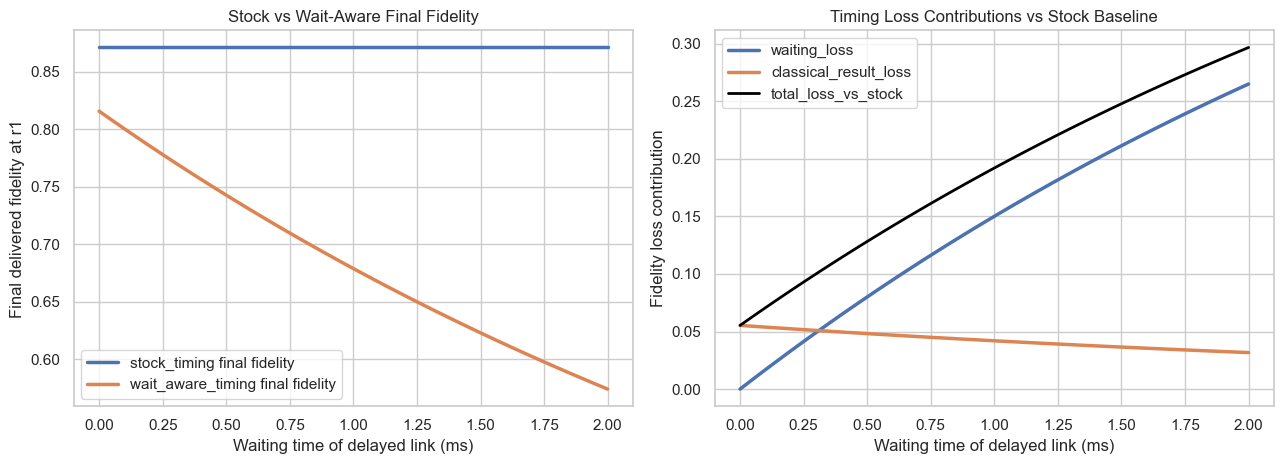

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
x = decomp_df['wait_ms']

# Left: fidelity curves (requested re-add)
ax[0].plot(x, decomp_df['stock_final'], label='stock_timing final fidelity', linewidth=2.5)
ax[0].plot(x, decomp_df['waitaware_final'], label='wait_aware_timing final fidelity', linewidth=2.5)
ax[0].set_xlabel('Waiting time of delayed link (ms)')
ax[0].set_ylabel('Final delivered fidelity at r1')
ax[0].set_title('Stock vs Wait-Aware Final Fidelity')
ax[0].legend(loc='best')

# Right: contribution decomposition
ax[1].plot(x, decomp_df['waiting_loss'], label='waiting_loss', linewidth=2.5)
ax[1].plot(x, decomp_df['classical_result_loss'], label='classical_result_loss', linewidth=2.5)
ax[1].plot(x, decomp_df['total_loss_vs_stock'], label='total_loss_vs_stock', linewidth=2.0, color='black')
ax[1].set_xlabel('Waiting time of delayed link (ms)')
ax[1].set_ylabel('Fidelity loss contribution')
ax[1].set_title('Timing Loss Contributions vs Stock Baseline')
ax[1].legend(loc='best')

plt.tight_layout()


In [7]:
summary = decomp_df[['waiting_loss','classical_result_loss','total_loss_vs_stock']].agg(['mean','max'])
summary


,waiting_loss,classical_result_loss,total_loss_vs_stock
mean,0.144031,0.042499,0.186530
max,0.265014,0.055334,0.296732


## Interpretation of Classical vs Waiting Contributions

Observed behavior in the contribution plot:

1. **Why classical-result loss starts nonzero at waiting = 0 ms**
   Even when pre-swap waiting is zero, the swap result still travels over a classical channel with nonzero delay.
   During that transit window (`swap_time -> receive_time`), memories continue to decohere, so a nonzero classical-result contribution is expected.

2. **Why waiting loss grows with waiting time**
   As one elementary link waits longer before swap, its memory is older at swap time, so swap-time fidelity decreases more.
   This appears directly as increasing `waiting_loss`.

3. **Why classical-result contribution can trend downward while waiting grows**
   Classical delay is fixed, but it acts on the swap-time fidelity value entering that stage.
   When waiting is large, swap-time fidelity is already lower, so the same transit-delay interval may produce a smaller additional absolute drop than at high initial fidelity.

4. **Takeaway**
   The dominant new effect from the fix is the pre-swap waiting term.
   Classical-result transit remains physically present, but its absolute contribution depends on the fidelity level at which the transit starts.
